In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Task 1: Dataset Exploration

In [2]:
columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

In [3]:
df = pd.read_csv("/content/data_banknote_authentication.txt", header=None, names=columns)

In [4]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
df.shape

(1372, 5)

In [6]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [7]:
df.isnull().values.any()

np.False_

In [8]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


Task 2: Exploratory Data Analysis

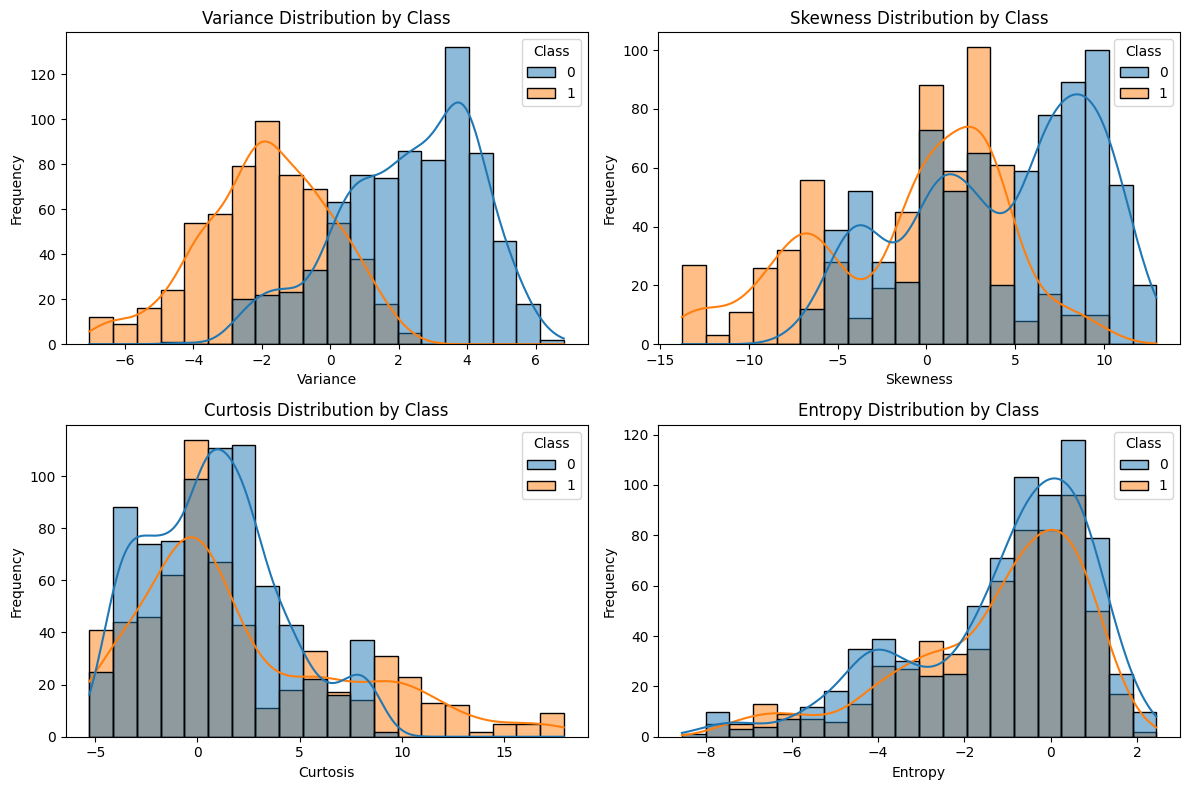

In [10]:
features = ["Variance", "Skewness", "Curtosis", "Entropy"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        kde=True,
        bins=20,
        ax=ax,
        alpha=0.5
    )

    ax.set_title(f"{feature} Distribution by Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "Feature_Distributions_by_Class.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

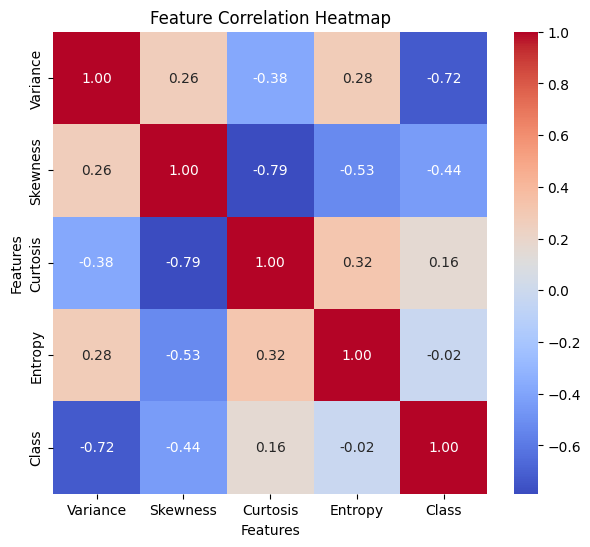

In [11]:
plt.figure(figsize=(7,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.savefig("Correlation_Heatmap.eps", format="eps", dpi=600, bbox_inches="tight")
plt.savefig(
    "Correlation_Heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

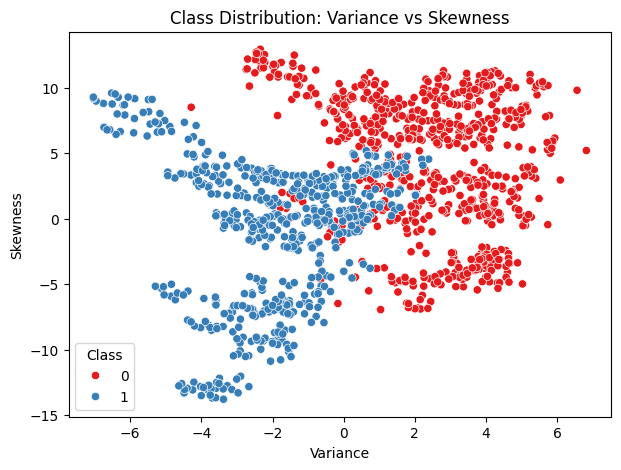

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Class Distribution: Variance vs Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.legend(title="Class")
plt.savefig(
    "Scatter_Plots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

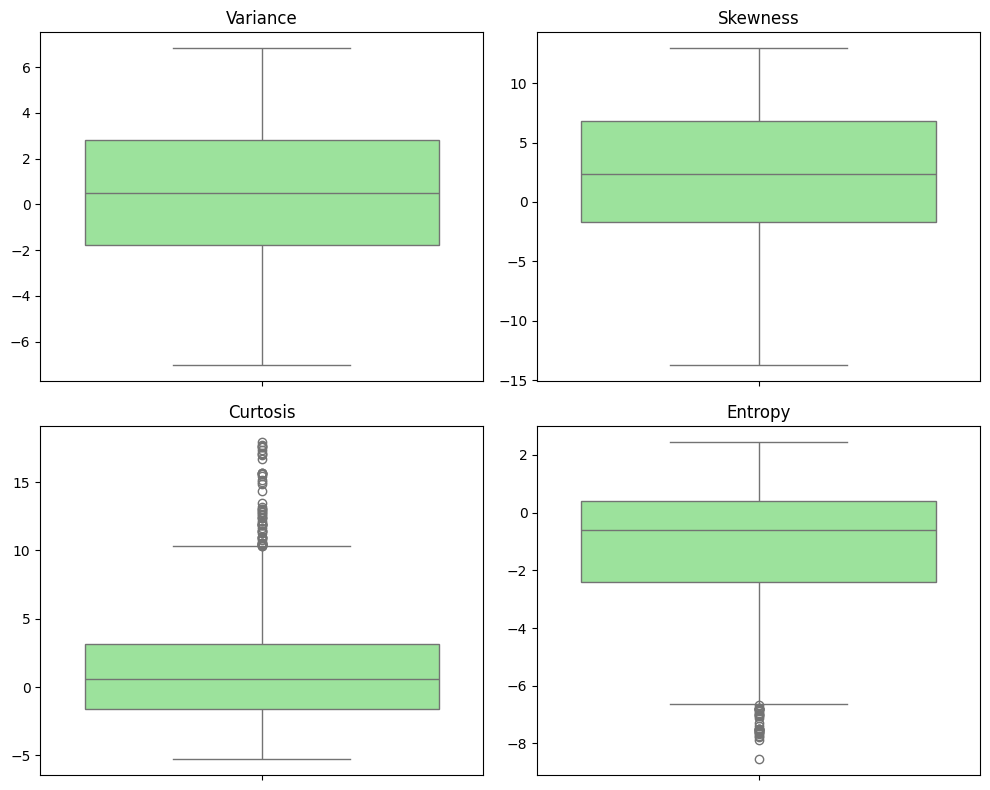

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightgreen')
    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "Feature_Boxplots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Task 3: Data Preprocessing

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [15]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1097, 4)
Testing Features: (275, 4)
Training Labels: (1097,)
Testing Labels: (275,)


Task 4: Perceptron Implementation

In [18]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []
        self.weights_history = []
        self.bias_history = []

    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = np.array([self.activation(x) for x in linear_output])
        return predictions

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for epoch in range(self.epochs):
            misclassified = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(linear_output)
                error = y[i] - prediction
                if error != 0:
                    misclassified += 1
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
            self.errors.append(misclassified)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}/{self.epochs}")
            print("Misclassified Samples:", misclassified)
            print("Updated Weights:", self.weights)
            print("Updated Bias:", self.bias)
            print("-" * 40)

Task 5: Model Training

In [19]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(X_train.values, y_train.values)

Epoch 1/100
Misclassified Samples: 171
Updated Weights: [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Updated Bias: 0.07
----------------------------------------
Epoch 2/100
Misclassified Samples: 101
Updated Weights: [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Updated Bias: 0.09999999999999999
----------------------------------------
Epoch 3/100
Misclassified Samples: 43
Updated Weights: [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Updated Bias: 0.10999999999999999
----------------------------------------
Epoch 4/100
Misclassified Samples: 43
Updated Weights: [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Updated Bias: 0.11999999999999998
----------------------------------------
Epoch 5/100
Misclassified Samples: 57
Updated Weights: [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Updated Bias: 0.12999999999999998
----------------------------------------
Epoch 6/100
Misclassified Samples: 43
Updated Weights: [-0.0971687  -0.10179894 -0.10908865  0.0144443 ]
Updated 

Task 6: Model Evaluation

In [20]:
y_pred = perceptron.predict(X_test.values)

In [21]:
accuracy = accuracy_score(y_test.values, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9890909090909091


In [22]:
precision = precision_score(y_test.values, y_pred)

print("Precision:", precision)

Precision: 0.9917355371900827


In [23]:
recall = recall_score(y_test.values, y_pred)

print("Recall:", recall)

Recall: 0.9836065573770492


In [24]:
f1 = f1_score(y_test.values, y_pred)

print("F1-score:", f1)

F1-score: 0.9876543209876543


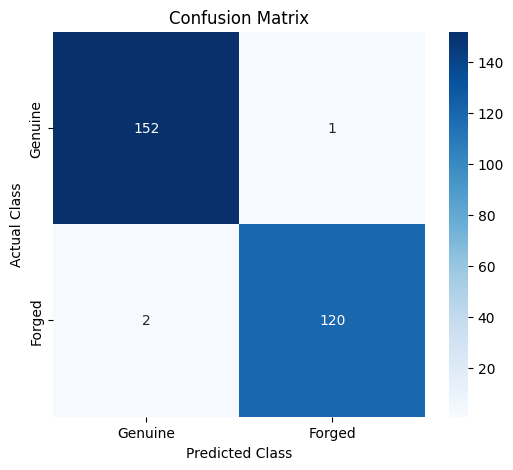

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test.values,y_pred)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine","Forged"],
    yticklabels=["Genuine","Forged"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.savefig(
    "Confusion_Matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

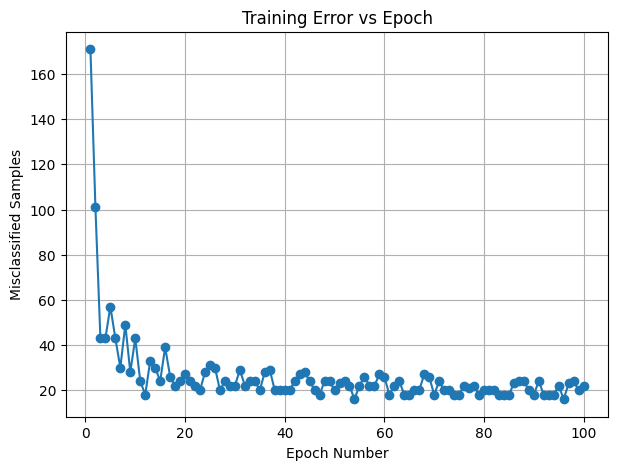

In [26]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,len(perceptron.errors)+1),
    perceptron.errors,
    marker="o"
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch Number")
plt.ylabel("Misclassified Samples")
plt.grid()
plt.savefig(
    "Training_Error_Vs_Epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

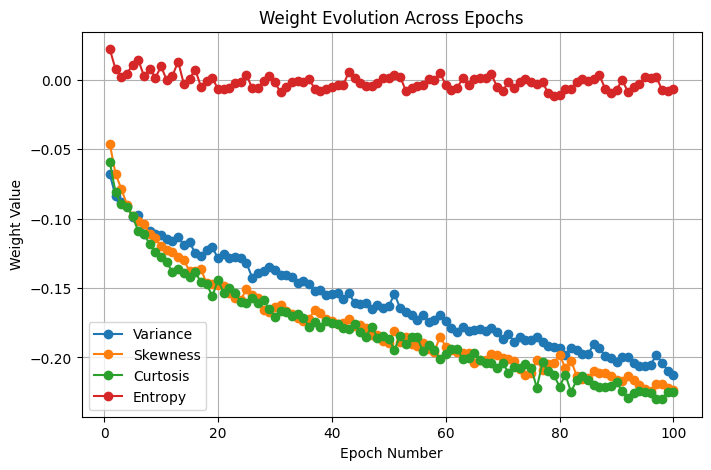

In [27]:
weights_history = np.array(perceptron.weights_history)

plt.figure(figsize=(8,5))

for i, feature in enumerate(features):
    plt.plot(
        range(1,len(weights_history)+1),
        weights_history[:,i],
        marker="o",
        label=feature
    )

plt.title("Weight Evolution Across Epochs")
plt.xlabel("Epoch Number")
plt.ylabel("Weight Value")
plt.legend()
plt.grid()
plt.savefig(
    "Weight_Evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

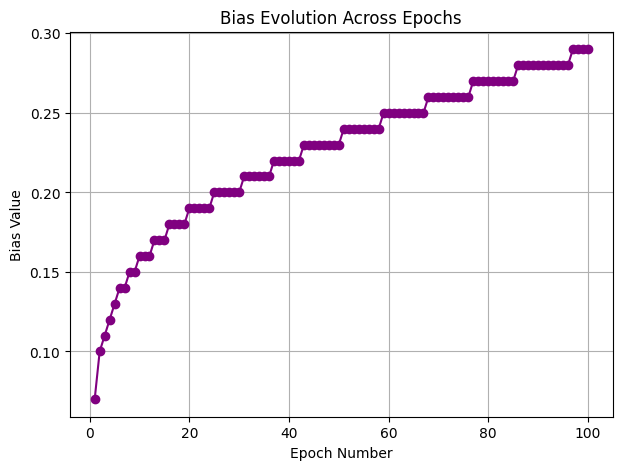

In [28]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,len(perceptron.bias_history)+1),
    perceptron.bias_history,
    marker="o",
    color="purple"
)

plt.title("Bias Evolution Across Epochs")
plt.xlabel("Epoch Number")
plt.ylabel("Bias Value")
plt.grid()
plt.savefig(
    "Bias_Evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Epoch 1/50
Misclassified Samples: 171
Updated Weights: [-0.00679236 -0.00461728 -0.00590423  0.00221363]
Updated Bias: 0.007
----------------------------------------
Epoch 2/50
Misclassified Samples: 101
Updated Weights: [-0.00838051 -0.00677447 -0.00810598  0.00077559]
Updated Bias: 0.010000000000000002
----------------------------------------
Epoch 3/50
Misclassified Samples: 43
Updated Weights: [-0.00878054 -0.00782712 -0.00894526  0.00024027]
Updated Bias: 0.011000000000000003
----------------------------------------
Epoch 4/50
Misclassified Samples: 43
Updated Weights: [-0.00908198 -0.00897889 -0.00912327  0.00043911]
Updated Bias: 0.012000000000000004
----------------------------------------
Epoch 5/50
Misclassified Samples: 57
Updated Weights: [-0.00987896 -0.00982728 -0.00983637  0.00110804]
Updated Bias: 0.013000000000000005
----------------------------------------
Epoch 6/50
Misclassified Samples: 43
Updated Weights: [-0.00971687 -0.01017989 -0.01090887  0.00144443]
Updated B

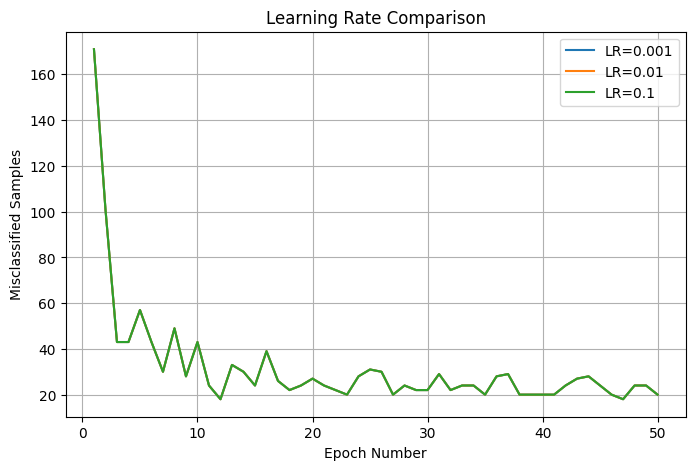

In [29]:
learning_rates = [0.001,0.01,0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=50
    )

    model.fit(X_train.values,y_train.values)

    plt.plot(
        range(1,len(model.errors)+1),
        model.errors,
        label=f"LR={lr}"
    )


plt.title("Learning Rate Comparison")
plt.xlabel("Epoch Number")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid()
plt.savefig(
    "Learning_Rate_Comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()